# 📝 Notebook 3: Procesamiento de Lenguaje Natural (NLP)
## Word Embedding, Ideas Centrales y Análisis de Sentimientos

Este notebook cubre tres técnicas fundamentales de NLP:

| Sección | Técnica | Dataset |
|---------|---------|----------|
| A | Preprocesamiento y TF-IDF | Reseñas de productos |
| B | Word Embedding (Word2Vec) | Corpus propio |
| C | Análisis de Sentimientos | Twitter/Reseñas |

### Criterio: CR3
Implementación de técnicas NLP para solucionar problemas de comunicación humano-computador.

In [8]:
# Instalación de dependencias
!pip install -q gensim nltk scikit-learn matplotlib seaborn wordcloud transformers torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter
import re, string, warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('vader_lexicon', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, SnowballStemmer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Gensim
from gensim.models import Word2Vec

# WordCloud
from wordcloud import WordCloud

# TensorFlow para el modelo de sentimientos
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb

print('✅ Todas las librerías cargadas correctamente.')

✅ Todas las librerías cargadas correctamente.


---
# PARTE A: Preprocesamiento de Texto y Extracción de Ideas Clave
## 1. Creación del Corpus de Reseñas

In [9]:
# Dataset de reseñas de productos electrónicos (en inglés para compatibilidad con herramientas NLP)
corpus_data = {
    'text': [
        "This smartphone has an absolutely amazing camera quality and the battery lasts all day. The screen is bright and responsive. Highly recommend!",
        "Terrible product. The battery dies within 3 hours and the software crashes constantly. Very disappointed with this purchase.",
        "Great value for money. The laptop runs fast, has good RAM, and the keyboard is comfortable for long typing sessions.",
        "The headphones have incredible sound quality and noise cancellation is perfect for travel and commuting on public transport.",
        "Overpriced and underwhelming. The build quality is poor and the device gets very hot during normal use.",
        "Outstanding customer service and fast shipping. The tablet arrived in perfect condition and works flawlessly.",
        "The smartwatch tracks fitness data accurately. Heart rate monitoring and sleep tracking work very well.",
        "Poor product. Screen broke after 2 weeks of normal use. The company refused to offer a replacement or refund.",
        "Excellent performance for gaming. The GPU handles all modern games smoothly at maximum settings.",
        "Average product. Nothing special about it. The price is reasonable but there are better options available.",
        "Love this wireless charger. It charges quickly and is compatible with all my devices including phone and earbuds.",
        "The camera photos are blurry in low light conditions and the zoom quality is very disappointing for the price.",
        "Best laptop I have ever owned. Lightweight, powerful processor, and the battery life is exceptional for work travel.",
        "The speaker sound is tinny and weak. Does not fill a room and the bluetooth connection drops frequently.",
        "Amazing product with incredible features. The setup was easy and the performance exceeded all my expectations.",
        "Terrible experience overall. The device stopped working after one month and support was unhelpful and rude.",
        "Very happy with this purchase. The ergonomic design reduces wrist fatigue and improves productivity significantly.",
        "The display resolution is sharp and the color accuracy is perfect for photo and video editing professionals.",
        "Mediocre performance and outdated software. Not worth the money when better alternatives exist at lower price.",
        "Fantastic smart home device. Easy to set up, voice recognition is accurate and it integrates with everything."
    ],
    'label': [1,0,1,1,0,1,1,0,1,0,1,0,1,0,1,0,1,1,0,1]  # 1=positivo, 0=negativo
}

df = pd.DataFrame(corpus_data)
print(f'Dataset: {len(df)} reseñas')
print(f'Positivas: {df.label.sum()} | Negativas: {(df.label==0).sum()}')
df.head()

Dataset: 20 reseñas
Positivas: 12 | Negativas: 8


,text,label
0,This smartphone has an absolutely amazing came...,1
1,Terrible product. The battery dies within 3 ho...,0
2,"Great value for money. The laptop runs fast, h...",1
3,The headphones have incredible sound quality a...,1
4,Overpriced and underwhelming. The build qualit...,0


## 2. Preprocesamiento de Texto

In [10]:
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess_text(text):
    """
    Pipeline de preprocesamiento NLP:
    1. Minúsculas
    2. Eliminar puntuación y números
    3. Tokenización
    4. Eliminación de stopwords
    5. Lematización
    """
    # 1. Minúsculas
    text = text.lower()
    # 2. Eliminar puntuación y números
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 3. Tokenización
    tokens = word_tokenize(text)
    # 4. Eliminar stopwords (tokens cortos también)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # 5. Lematización
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['text_clean'] = df['text'].apply(preprocess_text)

# Mostrar comparación antes/después
print('=== Ejemplo de Preprocesamiento ===\n')
for i in [0, 1]:
    print(f'ORIGINAL:   {df["text"].iloc[i]}')
    print(f'PROCESADO:  {df["text_clean"].iloc[i]}')
    print()

=== Ejemplo de Preprocesamiento ===

ORIGINAL:   This smartphone has an absolutely amazing camera quality and the battery lasts all day. The screen is bright and responsive. Highly recommend!
PROCESADO:  smartphone absolutely amazing camera quality battery last day screen bright responsive highly recommend

ORIGINAL:   Terrible product. The battery dies within 3 hours and the software crashes constantly. Very disappointed with this purchase.
PROCESADO:  terrible product battery dy within hour software crash constantly disappointed purchase



## 3. Nube de Palabras y Palabras Más Frecuentes

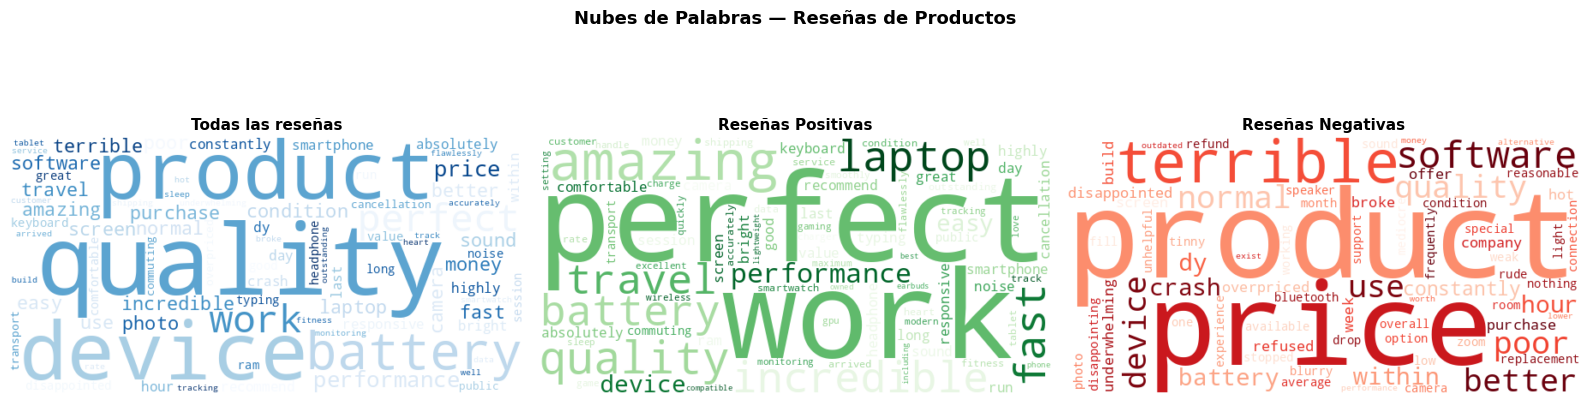

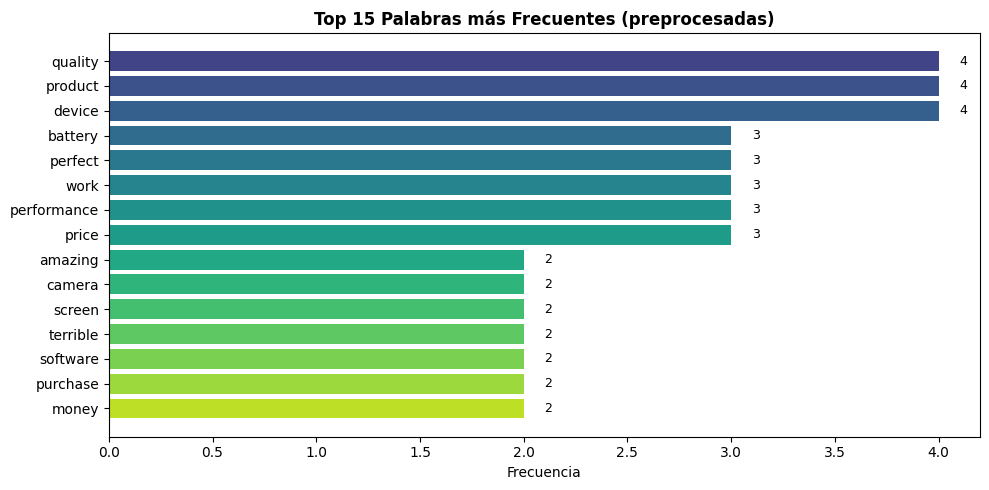

In [11]:
# Nube de palabras general y por sentimiento
def generate_wordcloud(texts, title, ax, colormap='viridis'):
    full_text = ' '.join(texts)
    wc = WordCloud(
        width=600, height=300,
        background_color='white',
        max_words=80,
        colormap=colormap,
        collocations=False
    ).generate(full_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
generate_wordcloud(df['text_clean'],                      'Todas las reseñas',  axes[0], 'Blues')
generate_wordcloud(df[df.label==1]['text_clean'],         'Reseñas Positivas',  axes[1], 'Greens')
generate_wordcloud(df[df.label==0]['text_clean'],         'Reseñas Negativas',  axes[2], 'Reds')
plt.suptitle('Nubes de Palabras — Reseñas de Productos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nlp_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 15 palabras más frecuentes
all_words = ' '.join(df['text_clean']).split()
word_freq  = Counter(all_words).most_common(15)

fig, ax = plt.subplots(figsize=(10, 5))
words, freqs = zip(*word_freq)
bars = ax.barh(words, freqs, color=plt.cm.viridis(np.linspace(0.2, 0.9, 15)))
ax.set_title('Top 15 Palabras más Frecuentes (preprocesadas)', fontweight='bold')
ax.set_xlabel('Frecuencia')
ax.invert_yaxis()
for bar, freq in zip(bars, freqs):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(freq), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('nlp_word_freq.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. TF-IDF: Palabras más Relevantes por Documento

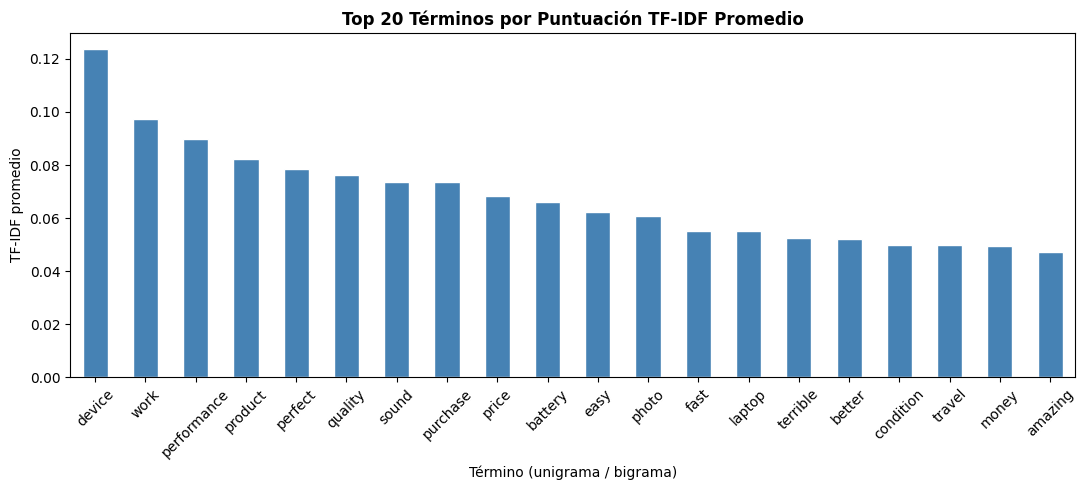

Top 10 términos más relevantes según TF-IDF:
  device                    0.1236
  work                      0.0974
  performance               0.0898
  product                   0.0825
  perfect                   0.0785
  quality                   0.0763
  sound                     0.0736
  purchase                  0.0736
  price                     0.0684
  battery                   0.0662


In [12]:
# TF-IDF para identificar las palabras más relevantes
tfidf = TfidfVectorizer(max_features=30, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df['text_clean'])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

# Top palabras por TF-IDF promedio
tfidf_mean = tfidf_df.mean().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 5))
tfidf_mean.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Términos por Puntuación TF-IDF Promedio', fontweight='bold')
ax.set_xlabel('Término (unigrama / bigrama)')
ax.set_ylabel('TF-IDF promedio')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('nlp_tfidf_terms.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 términos más relevantes según TF-IDF:')
for term, score in tfidf_mean.head(10).items():
    print(f'  {term:<25} {score:.4f}')

## 5. LDA — Modelado de Tópicos

=== Tópicos descubiertos por LDA ===

Tópico 1 (Rendimiento): device, perfect, fast, condition, photo, terrible, work
Tópico 2 (Experiencia usuario): performance, price, incredible, better, product, sound, money
Tópico 3 (Audio/Display): quality, product, use, normal, poor, purchase, terrible
Tópico 4 (Calidad/Precio): battery, work, laptop, quality, camera, screen, travel


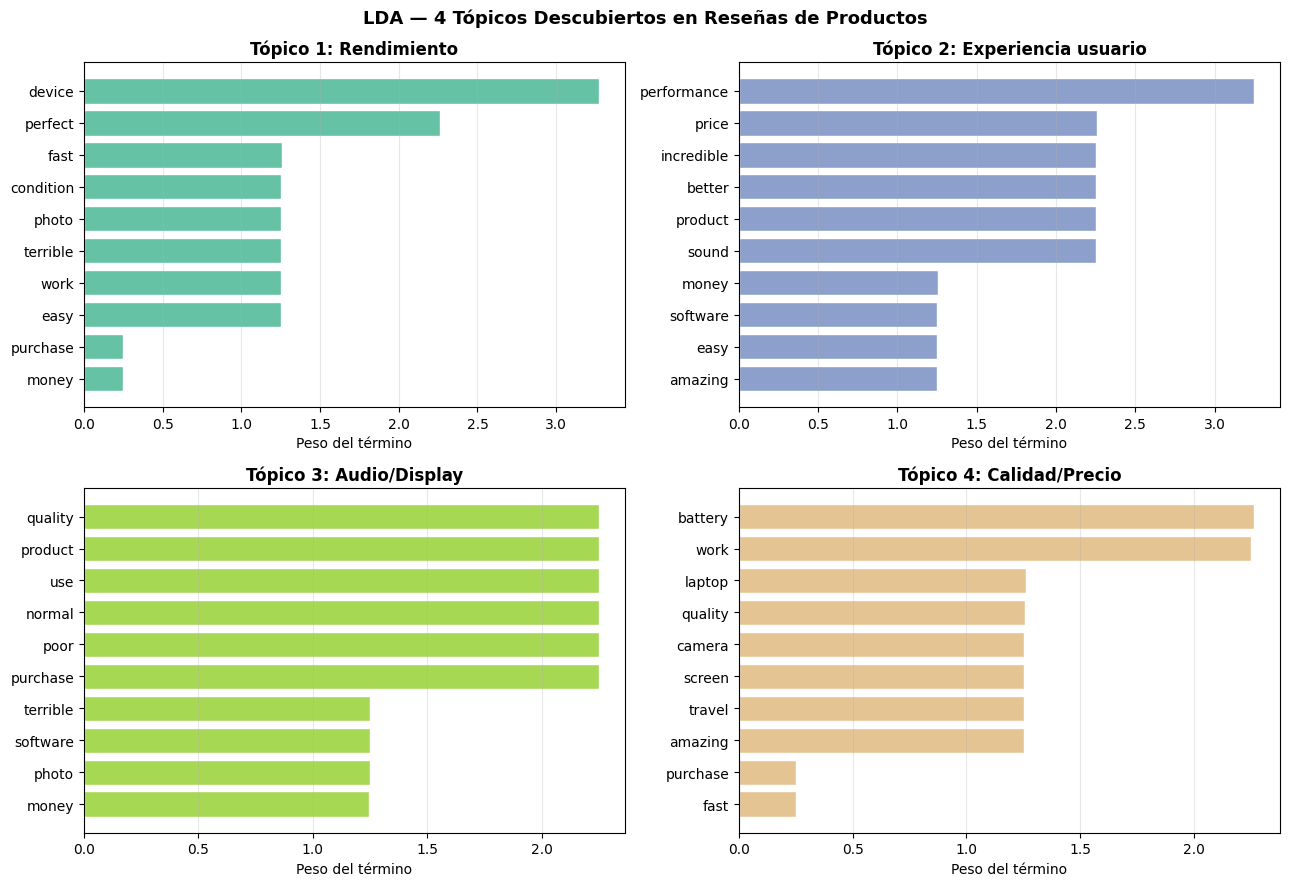

In [13]:
# LDA: descubrir tópicos latentes en el corpus
count_vec = CountVectorizer(max_features=50, min_df=2)
count_matrix = count_vec.fit_transform(df['text_clean'])

lda = LatentDirichletAllocation(n_components=4, random_state=42, max_iter=20)
lda.fit(count_matrix)

feature_names = count_vec.get_feature_names_out()
topics_labels = ['Rendimiento', 'Experiencia usuario', 'Audio/Display', 'Calidad/Precio']

print('=== Tópicos descubiertos por LDA ===\n')
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('LDA — 4 Tópicos Descubiertos en Reseñas de Productos', fontsize=13, fontweight='bold')

for i, (ax, topic) in enumerate(zip(axes.flat, lda.components_)):
    top_n = 10
    top_idx   = topic.argsort()[-top_n:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    top_probs = [topic[j] for j in top_idx]

    ax.barh(top_words[::-1], top_probs[::-1],
            color=plt.cm.Set2(i / 4), edgecolor='white')
    ax.set_title(f'Tópico {i+1}: {topics_labels[i]}', fontweight='bold')
    ax.set_xlabel('Peso del término')
    ax.grid(True, axis='x', alpha=0.3)
    print(f'Tópico {i+1} ({topics_labels[i]}): {", ".join(top_words[:7])}')

plt.tight_layout()
plt.savefig('nlp_lda_topics.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PARTE B: Word Embedding con Word2Vec

In [14]:
# Preparar corpus tokenizado para Word2Vec
sentences = [text.split() for text in df['text_clean']]

# Entrenar modelo Word2Vec
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=50,   # dimensión del vector
    window=5,          # contexto de ventana
    min_count=1,       # frecuencia mínima
    workers=2,
    epochs=100,
    sg=0               # 0=CBOW, 1=Skip-gram
)

print(f'Vocabulario Word2Vec: {len(w2v_model.wv)} palabras')
print(f'Dimensión de vectores: {w2v_model.wv.vector_size}')

# Similitud entre palabras
test_words = ['good', 'battery', 'quality', 'terrible']
print('\n=== Palabras más similares (Word2Vec) ===')
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f'\n"{word}" → {[(w, round(s,3)) for w,s in similar]}')

Vocabulario Word2Vec: 178 palabras
Dimensión de vectores: 50

=== Palabras más similares (Word2Vec) ===

"good" → [('quality', 0.881), ('performance', 0.846), ('gpu', 0.845), ('device', 0.843), ('fast', 0.838)]

"battery" → [('device', 0.921), ('performance', 0.906), ('perfect', 0.897), ('fast', 0.886), ('quality', 0.881)]

"quality" → [('fast', 0.913), ('device', 0.91), ('performance', 0.903), ('perfect', 0.898), ('stopped', 0.895)]

"terrible" → [('poor', 0.858), ('device', 0.855), ('tablet', 0.843), ('work', 0.839), ('build', 0.837)]


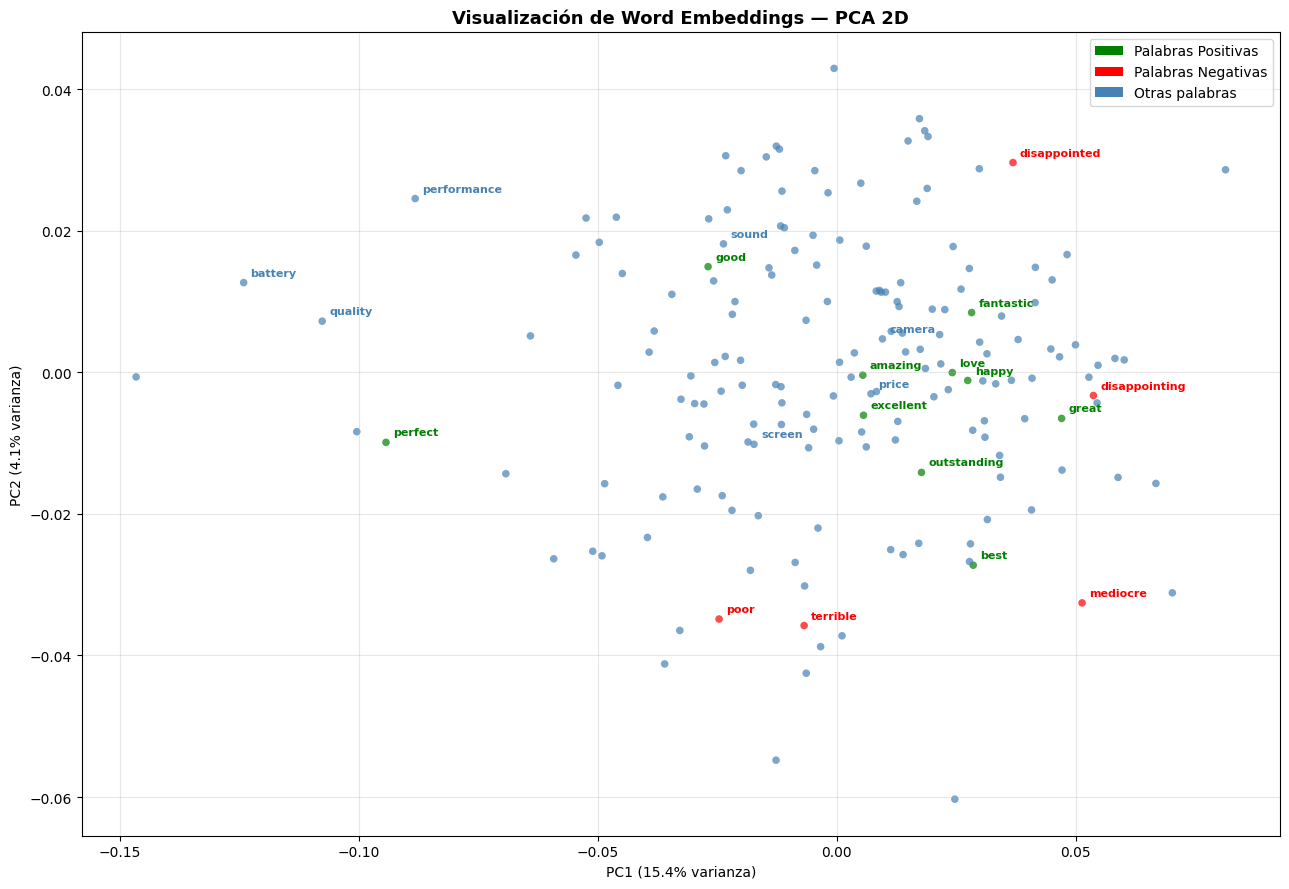

Varianza explicada: PC1=15.4%, PC2=4.1%


In [15]:
# Visualización de embeddings con PCA 2D
vocab_words = list(w2v_model.wv.key_to_index.keys())
vectors = np.array([w2v_model.wv[w] for w in vocab_words])

pca = PCA(n_components=2, random_state=42)
vectors_2d = pca.fit_transform(vectors)

# Categorización de palabras para colorear
positive_words = {'good', 'great', 'excellent', 'amazing', 'perfect', 'best',
                  'fantastic', 'outstanding', 'love', 'happy', 'wonderful', 'awesome'}
negative_words = {'terrible', 'poor', 'bad', 'worst', 'awful', 'disappointed',
                  'horrible', 'mediocre', 'disappointing', 'useless', 'broken'}

def get_color(word):
    if word in positive_words: return 'green'
    if word in negative_words: return 'red'
    return 'steelblue'

colors = [get_color(w) for w in vocab_words]

fig, ax = plt.subplots(figsize=(13, 9))
ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1],
           c=colors, s=30, alpha=0.7, edgecolors='none')

# Anotar palabras importantes
important = positive_words | negative_words | {'battery', 'quality', 'performance',
                                                 'camera', 'price', 'screen', 'sound'}
for word, (x, y), color in zip(vocab_words, vectors_2d, colors):
    if word in important:
        ax.annotate(word, (x, y), xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color=color, fontweight='bold' if word in important else 'normal')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='Palabras Positivas'),
                   Patch(facecolor='red',   label='Palabras Negativas'),
                   Patch(facecolor='steelblue', label='Otras palabras')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax.set_title('Visualización de Word Embeddings — PCA 2D', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nlp_word2vec_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Varianza explicada: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

---
# PARTE C: Análisis de Sentimientos
## Método 1: VADER (Léxico)
## Método 2: Regresión Logística + TF-IDF
## Método 3: Red Neuronal con Embedding

=== VADER Accuracy: 0.9500 (95.0%) ===


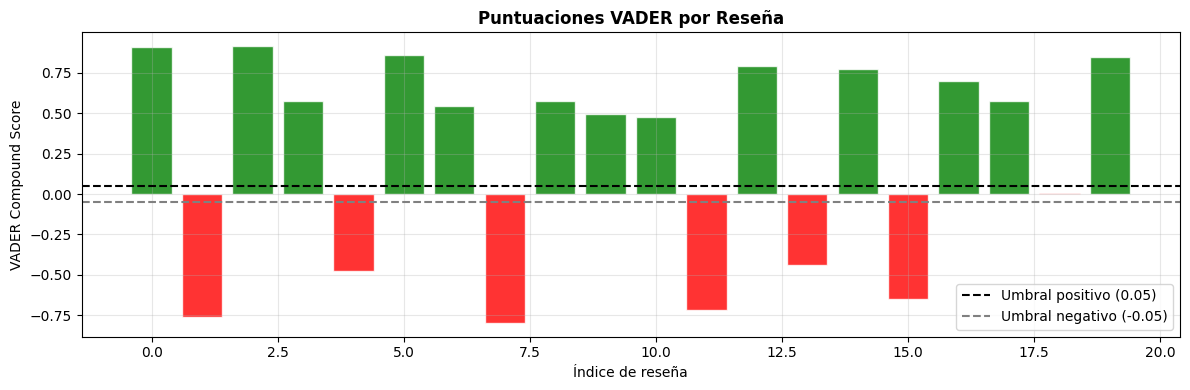

In [16]:
# === MÉTODO 1: VADER ===
sia = SentimentIntensityAnalyzer()

def vader_classify(text):
    score = sia.polarity_scores(text)['compound']
    return 1 if score >= 0.05 else 0

df['vader_pred']  = df['text'].apply(vader_classify)
df['vader_score'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])

vader_acc = accuracy_score(df['label'], df['vader_pred'])
print(f'=== VADER Accuracy: {vader_acc:.4f} ({vader_acc*100:.1f}%) ===')

# Visualizar scores VADER
fig, ax = plt.subplots(figsize=(12, 4))
colors_v = ['green' if s >= 0.05 else 'red' for s in df['vader_score']]
ax.bar(range(len(df)), df['vader_score'], color=colors_v, edgecolor='white', alpha=0.8)
ax.axhline(0.05, color='black', linestyle='--', linewidth=1.5, label='Umbral positivo (0.05)')
ax.axhline(-0.05, color='gray', linestyle='--', linewidth=1.5, label='Umbral negativo (-0.05)')
ax.set_title('Puntuaciones VADER por Reseña', fontweight='bold')
ax.set_xlabel('Índice de reseña')
ax.set_ylabel('VADER Compound Score')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nlp_vader_scores.png', dpi=150, bbox_inches='tight')
plt.show()

=== Regresión Logística + TF-IDF ===
CV Accuracy (5-fold): 0.6000 ± 0.1225


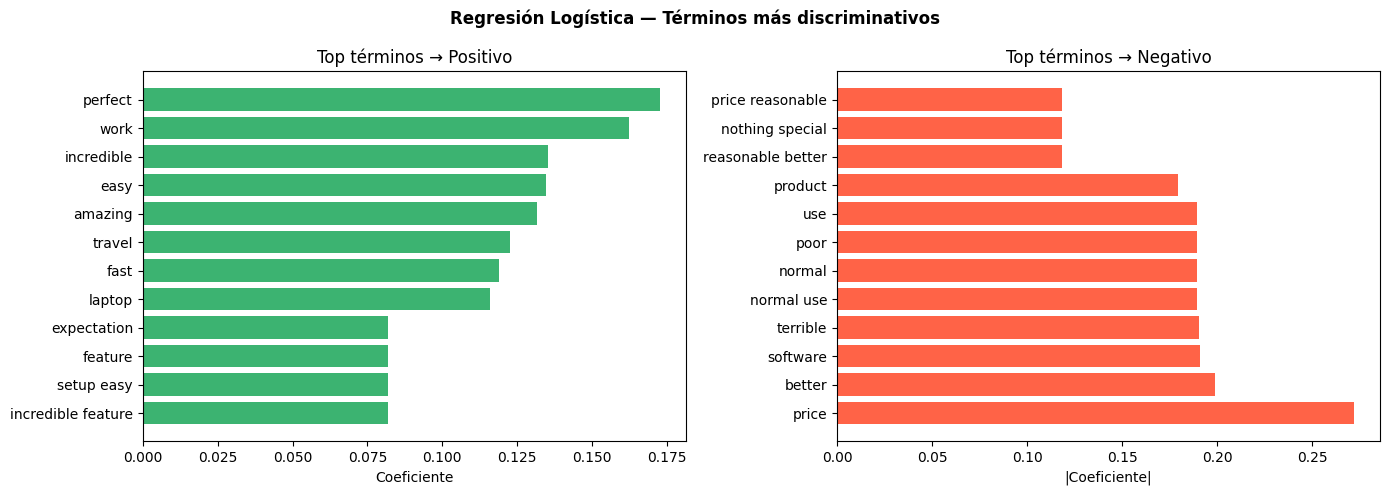

In [17]:
# === MÉTODO 2: Regresión Logística + TF-IDF ===
tfidf_clf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), sublinear_tf=True)
X_tfidf   = tfidf_clf.fit_transform(df['text_clean'])
y         = df['label'].values

# Con dataset pequeño, usamos leave-one-out manual
from sklearn.model_selection import cross_val_score
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
cv_scores = cross_val_score(lr_model, X_tfidf, y, cv=5, scoring='accuracy')

print(f'=== Regresión Logística + TF-IDF ===')
print(f'CV Accuracy (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Entrenar en todo el set y mostrar importancia de features
lr_model.fit(X_tfidf, y)
feature_names_lr  = tfidf_clf.get_feature_names_out()
coefficients       = lr_model.coef_[0]

top_pos_idx = np.argsort(coefficients)[-12:][::-1]
top_neg_idx = np.argsort(coefficients)[:12]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regresión Logística — Términos más discriminativos', fontsize=12, fontweight='bold')

ax1.barh([feature_names_lr[i] for i in top_pos_idx][::-1],
         [coefficients[i] for i in top_pos_idx][::-1], color='mediumseagreen')
ax1.set_title('Top términos → Positivo'); ax1.set_xlabel('Coeficiente')

ax2.barh([feature_names_lr[i] for i in top_neg_idx],
         [abs(coefficients[i]) for i in top_neg_idx], color='tomato')
ax2.set_title('Top términos → Negativo'); ax2.set_xlabel('|Coeficiente|')

plt.tight_layout()
plt.savefig('nlp_lr_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# === MÉTODO 3: Red Neuronal con Embedding (dataset IMDb externo) ===
# Cargamos IMDb (50,000 reseñas reales) para un modelo robusto
VOCAB_SIZE = 8000
MAX_LEN    = 150
EMBED_DIM  = 32

(X_tr, y_tr), (X_te, y_te) = imdb.load_data(num_words=VOCAB_SIZE)
X_tr_pad = pad_sequences(X_tr, maxlen=MAX_LEN, padding='post')
X_te_pad = pad_sequences(X_te, maxlen=MAX_LEN, padding='post')

# Modelo compacto: Embedding + Conv1D + GlobalMaxPool + Dense
model_nlp = models.Sequential([
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    layers.Conv1D(64, 3, activation='relu', padding='same'),
    layers.GlobalMaxPooling1D(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model_nlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_nlp.summary()

history_nlp = model_nlp.fit(
    X_tr_pad, y_tr,
    epochs=8,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

loss_nlp, acc_nlp = model_nlp.evaluate(X_te_pad, y_te, verbose=0)
print(f'\n=== Red Neuronal (Embedding+Conv1D) ===')
print(f'Test Accuracy: {acc_nlp:.4f} ({acc_nlp*100:.2f}%)')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 175ms/step - accuracy: 0.6338 - loss: 0.6461 - val_accuracy: 0.7626 - val_loss: 0.5367
Epoch 2/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.7954 - loss: 0.4580 - val_accuracy: 0.8308 - val_loss: 0.3886
Epoch 3/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.8617 - loss: 0.3368 - val_accuracy: 0.8602 - val_loss: 0.3266
Epoch 4/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.9066 - loss: 0.2490 - val_accuracy: 0.8702 - val_loss: 0.3063
Epoch 5/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.9391 - loss: 0.1789 - val_accuracy: 0.8746 - val_loss: 0.3076
Epoch 6/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.9620 - loss: 0.1254 - val_accuracy: 0.8728 - val_loss: 0.3229
Epoch 7/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.9801 - loss: 0.0812 - val_accuracy: 0.8746 - val_loss: 0.3474
Epoch 8/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.9896 - loss: 0.0510 - val_accuracy: 0.8710 - val_

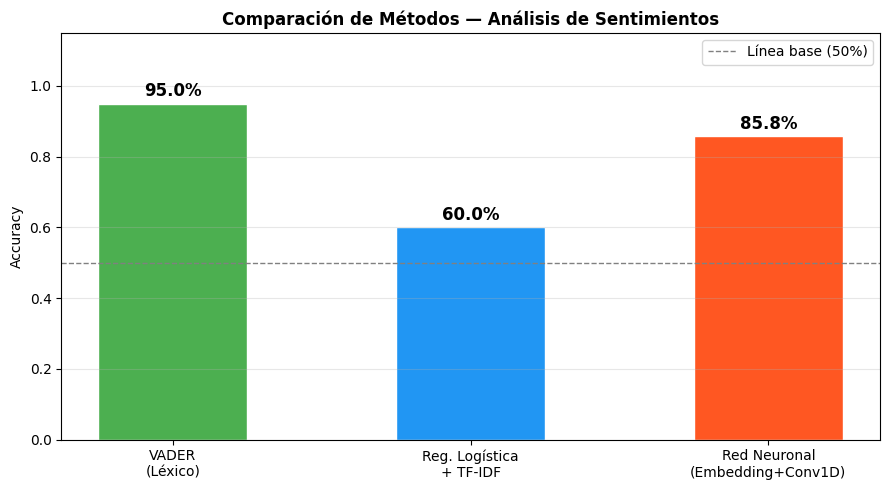


=== Resumen Final ===
  VADER (Léxico)                      Accuracy: 95.0%
  Reg. Logística + TF-IDF             Accuracy: 60.0%
  Red Neuronal (Embedding+Conv1D)     Accuracy: 85.8%

✅ Notebook NLP completado exitosamente!


In [19]:
# === COMPARACIÓN DE LOS 3 MÉTODOS ===
methods  = ['VADER\n(Léxico)', 'Reg. Logística\n+ TF-IDF', 'Red Neuronal\n(Embedding+Conv1D)']
accs     = [vader_acc, cv_scores.mean(), acc_nlp]
colors_m = ['#4CAF50', '#2196F3', '#FF5722']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(methods, accs, color=colors_m, edgecolor='white', width=0.5)
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Línea base (50%)')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{acc*100:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_title('Comparación de Métodos — Análisis de Sentimientos', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('nlp_methods_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Resumen Final ===')
for m, a in zip(methods, accs):
    print(f'  {m.replace(chr(10)," "):<35} Accuracy: {a*100:.1f}%')

print('\n✅ Notebook NLP completado exitosamente!')